In [1]:
import numpy as np
import xarray as xr
from frequensolve import *

project_path = "./scratch/ex_05/"
project = Project(
    name = "rtm",
    pretty_name = "Reverse Time Migration",
    path = project_path,
    load_if_exists = False,
)

sim = project.new_simulation(
    name = "sharp",
    physics = "elastic",
    dimension = 2,
    f0 = 1.0,
)

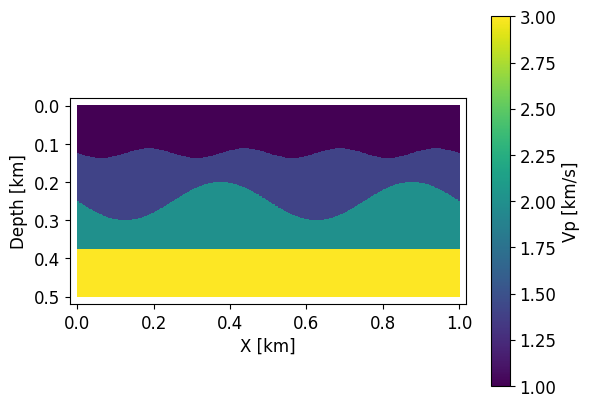

In [2]:
# New 2D layered model over interval x in [0,1]
model = LayeredModel(
    dimension = 2, 
    x_limits = [0.0, 1.0]
)
Q = 1e10

model.add_surface(name = "top", z = 0.0)
model.add_layer(
    name = "layer_1",
    properties = { 
        "Vp" : 1.0,
        "Qp" : Q,
        "Rho": 1.0,
        "Vs" : 0.5,
        "Qs" : Q,
    }
)

x = np.linspace(0.0, 1.0, 100)
surf = xr.DataArray(
    data = 0.125 + 0.0125*np.sin(x*8*np.pi),
    dims = ["x"],
    coords = {"x": x}
)
model.add_surface(name = "interface", z = surf)

model.add_layer(
    name = "layer_2",
    properties = { 
        "Vp" : 1.4,
        "Qp" : Q,
        "Rho": 1.4,
        "Vs" : 0.7,
        "Qs" : Q,
    }
)

surf = xr.DataArray(
    data = 0.25 + 0.05*np.sin(x*4*np.pi),
    dims = ["x"],
    coords = {"x": x}
)
model.add_surface(name = "sin",z = surf)

model.add_layer(
    name = "layer_2",
    properties = { 
        "Vp" : 2.0,
        "Qp" : Q,
        "Rho": 1.75,
        "Vs" : 1.0,
        "Qs" : Q,
    }
)
model.add_surface(name = "bottom", z = 0.375)

model.add_layer(
    name = "layer_2",
    properties = { 
        "Vp" : 3.0,
        "Qp" : Q,
        "Rho": 2.5,
        "Vs" : 1.5,
        "Qs" : Q,
    }
)
model.add_surface(name = "bottom", z = 0.5)

model.plot("Vp", aspect = "equal", surfaces = False)
sim += model

In [3]:
# Define a Hex mesh generator
mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh
sim.mesh.set_adapt(
    min_epw = {
        "x": 1.25, 
        "z": 1.25
    },
    adapt_sources = 1,
    f_low = 3.0,
    f_med = 5.0,
)

In [4]:
# New boundery condition manager
BCs = BoundaryConditionManager(
    label_type = "geometric"
)

# Free surface BC
BCs += BoundaryCondition(
    name = "free_surface",
    kind = "neumann",
    boundaries = ["z_min"]
)

# PML boundary condition
BCs += BoundaryCondition(
    name = "pml",
    kind = "pml",
    boundaries = ["x_min", "x_max", "z_max"],
    pml_wavelengths = 1.1,
    pml_exponent = 3.0,
    pml_constant = 20.0
)
sim += BCs

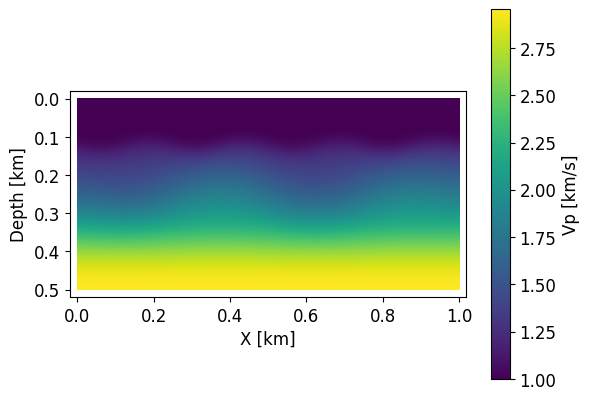

In [5]:
acq = Acquisition()

# Sources
# acq.add_source_group(
#     kind = "scalar",
#     coords = [ [x, 0.0] for x in np.linspace(0.0, 1.0, 128)]
# )
acq.add_source_group(
    kind = "vector",
    coords = [ [x, 0.0] for x in np.linspace(0.0, 1.0, 64) ],
    direction = [0., 1.0],
)

# # Hydrophones
# hydrophone = ReceiverNode(name = "hydrophone")
# hydrophone.add_component("p","pressure")
geophone = ReceiverNode(name = "geophone")
geophone.add_component("u_z","displacement",[0., 1.])

coords = [ [x, 0.0] for x in np.linspace(0.0, 1.0, 251)]
acq.add_receiver_group(
    name = "surface_hydrophones",
    device = geophone,
    coords = coords,
    post_process = True,
)
sim += acq

method = Discretization(
    order = {
        "x": 6,
        "z": 6,
    },
)
sim += method

solver = SolverConfig(
    solve_on = "final",
    max_iter = 300,
    tolerance = 5.0e-5,
)
sim += solver

out = OutputManager()
# out += ParaviewOutput(
#     name = "simple", 
#     fields = ["displacement"],
#     upscale = 1,
#     execute_on = "adjoint",
#     post_process = True,
# )
sim += out

smoothed = sim.copy(
    name = "smoothed",
    workflow = "RTM",
)
smoothed.model.smooth([1001,501], 60)
for key, value in sim.model.layers[0].properties.items():
    smoothed.model.layers[0].properties[key] = value
smoothed.model.smooth([1001,501], 20)
smoothed.model.plot("Vp", aspect = "equal", surfaces = False)
project += smoothed

project.save()
sharp = project.simulations["sharp"]
smooth = project.simulations["smoothed"]


20 20.0


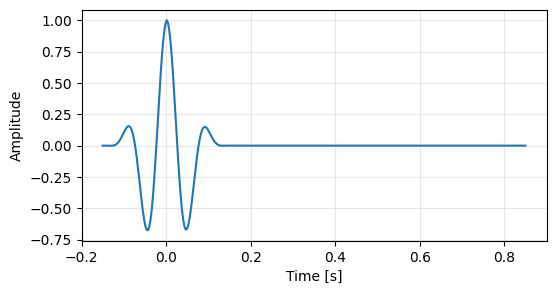

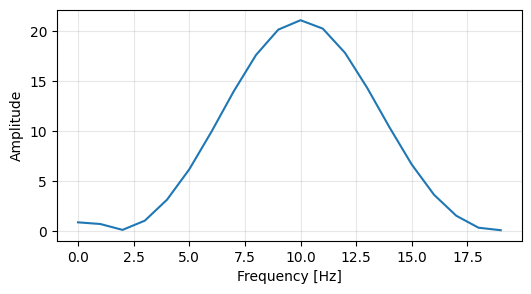

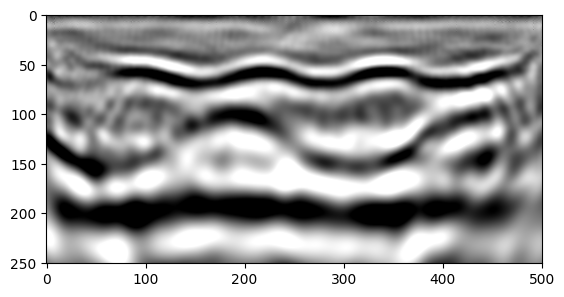

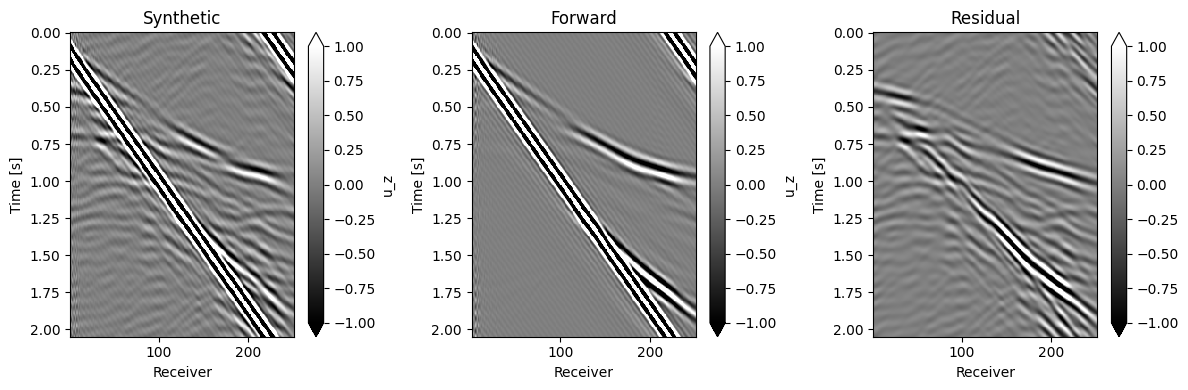

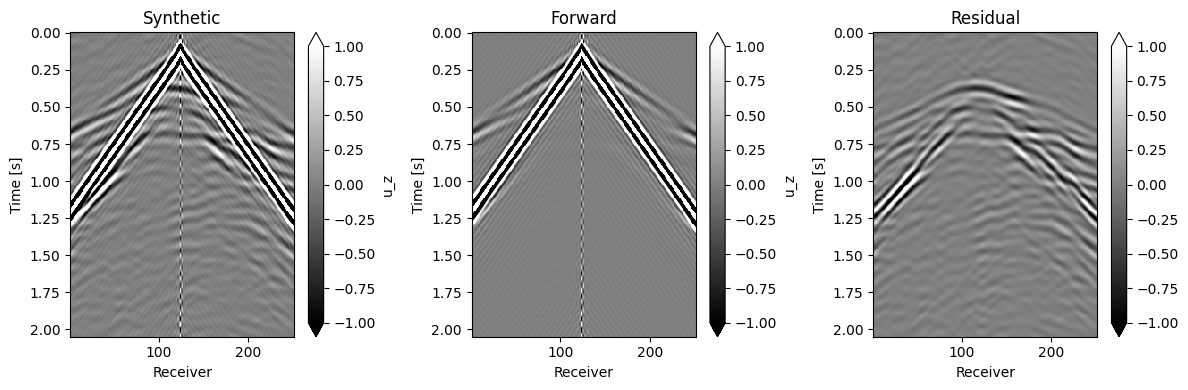

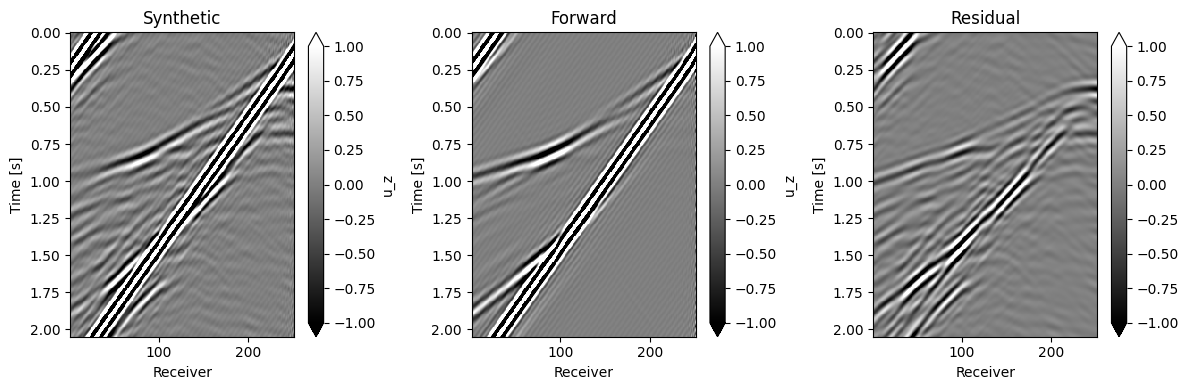

In [6]:
# --- Connect to site ---
   
site = "local"

if site == "local":
    site = LocalSite()
elif site == "stampede3":
    site = Stampede3Site(
        rel_path = "problems/ex_05/",
        default_queue = "spr",
    )
else:
    raise ValueError(f"Site {site} not supported; specify a valid site from options above.")
site.sync(project)

f_list = np.linspace(1,20,40)

synthetic = FrequencyDomainJob(
    name = "synthetic",
    simulation = sharp,
    f_list = f_list,
)

wavelet = KlauderWavelet(
    f = [6, 14],
    center = 0.15,
    window = ("blackman", 0.3),
)
wavelet.plot(f_max = 20)

rtm = RTMImagingJob(
    name = "rtm",
    simulation = smooth,
    f_list = synthetic.f_list,
    resolution = [501, 251],
    data_path = synthetic.trace_path,
    misfit_type = "L2",
    imaging_condition = "energy",
    keep_forward = True,
    keep_adjoint = True,
    save_path = "scratch/ex_05/outputs/smoothed/imaging/",
    wavelet = wavelet,
    normalize = 1.e-2
)

# site.submit(synthetic)
# site.submit(rtm)

syn_db = site.fetch_traces(synthetic, upscale = 4)
fwd_db = site.fetch_traces(rtm, upscale = 4)
img = site.fetch_image(rtm)

A = 10.0
plt.imshow(img, vmin=-A, vmax=A, cmap="gray")
plt.show()

for group in syn_db.groups:
    for shot in [1,32,64]:
        for comp in syn_db.components(group):
            td_syn = syn_db.read_TD(group, comp, shot, wavelet, upscale = 4)
            td_fwd = fwd_db.read_TD(group, comp, shot, wavelet, upscale = 4)

            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
            td_syn.plot(
                vmin = -1,
                vmax = 1,
                y = "time",
                yincrease = False,
                cmap = "gray",
                ax = ax1
            )
            ax1.set_title("Synthetic")
            td_fwd.plot(
                vmin = -1,
                vmax = 1,
                y = "time",
                yincrease = False,
                cmap = "gray",
                ax = ax2
            )
            ax2.set_title("Forward")
            (td_syn - td_fwd).plot(
                vmin = -1,
                vmax = 1,
                y = "time",
                yincrease = False,
                cmap = "gray",
                ax = ax3
            )
            ax3.set_title("Residual")
            plt.tight_layout()
            plt.show()
